In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv('/content/dataset_olympics.csv')

In [3]:
data

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,35656,Stuart Fitzsimmons,M,19.0,NaN,NaN,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Giant Slalom,NaN
69996,35656,Stuart Fitzsimmons,M,19.0,NaN,NaN,Great Britain,GBR,1976 Winter,1976,Winter,Innsbruck,Alpine Skiing,Alpine Skiing Men's Slalom,NaN
69997,35657,"David Thomas ""Dave"" Fitzsimons",M,26.0,170.0,65.0,Australia,AUS,1976 Summer,1976,Summer,Montreal,Athletics,"Athletics Men's 10,000 metres",NaN
69998,35657,"David Thomas ""Dave"" Fitzsimons",M,30.0,170.0,65.0,Australia,AUS,1980 Summer,1980,Summer,Moskva,Athletics,"Athletics Men's 5,000 metres",NaN


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      70000 non-null  int64  
 1   Name    70000 non-null  object 
 2   Sex     70000 non-null  object 
 3   Age     67268 non-null  float64
 4   Height  53746 non-null  float64
 5   Weight  52899 non-null  float64
 6   Team    70000 non-null  object 
 7   NOC     70000 non-null  object 
 8   Games   70000 non-null  object 
 9   Year    70000 non-null  int64  
 10  Season  70000 non-null  object 
 11  City    70000 non-null  object 
 12  Sport   70000 non-null  object 
 13  Event   70000 non-null  object 
 14  Medal   9690 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 8.0+ MB


In [5]:
data.describe()

,ID,Age,Height,Weight,Year
count,70000.000000,67268.000000,53746.000000,52899.000000,70000.000000
mean,18081.846986,25.644645,175.505303,70.900216,1977.766457
std,10235.613253,6.485239,10.384203,14.217489,30.103306
min,1.000000,11.000000,127.000000,25.000000,1896.000000
25%,9325.750000,21.000000,168.000000,61.000000,1960.000000
50%,18032.000000,25.000000,175.000000,70.000000,1984.000000
75%,26978.000000,28.000000,183.000000,79.000000,2002.000000
max,35658.000000,88.000000,223.000000,214.000000,2016.000000


In [7]:
data.describe(include='object')

,Name,Sex,Team,NOC,Games,Season,City,Sport,Event,Medal
count,70000,70000,70000,70000,70000,70000,70000,70000,70000,9690
unique,35556,2,827,226,51,2,42,65,744,3
top,Oksana Aleksandrovna Chusovitina,M,United States,USA,2016 Summer,Summer,London,Athletics,Football Men's Football,Gold
freq,29,51877,4979,5216,3675,58467,6034,10629,1738,3292


In [8]:
data.duplicated().sum()

383

In [9]:
data.drop_duplicates(inplace=True)

In [10]:
data.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

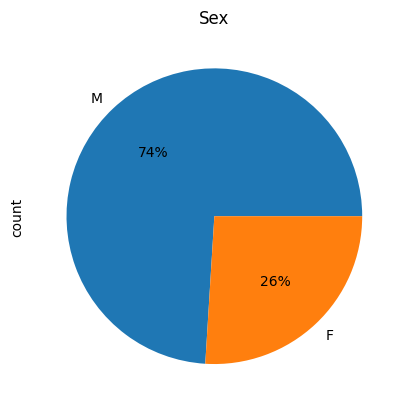

In [13]:
data["Sex"].value_counts().plot(kind = "pie", autopct = '%1.0f%%')
plt.title("Sex")
plt.show()

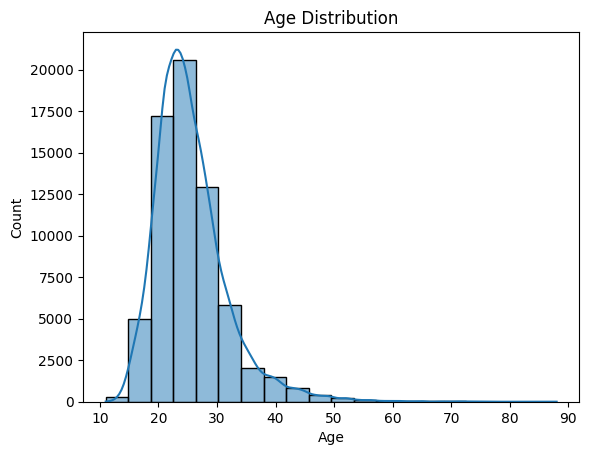

In [19]:
sns.histplot(data = data,x = 'Age', bins= 20, kde= True)
plt.title("Age Distribution")
plt.show()

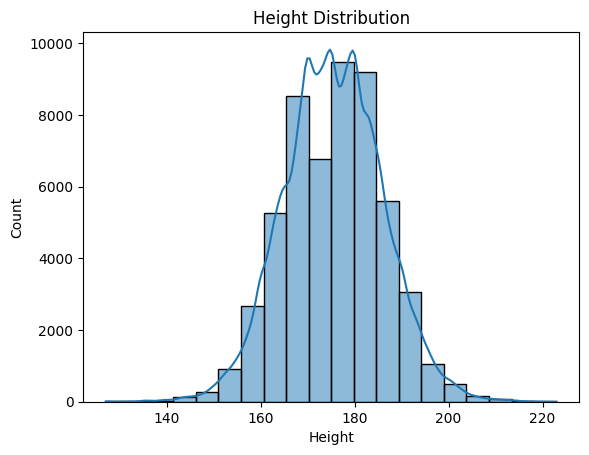

In [20]:
sns.histplot(data = data,x = 'Height', bins= 20, kde= True)
plt.title("Height Distribution")
plt.show()

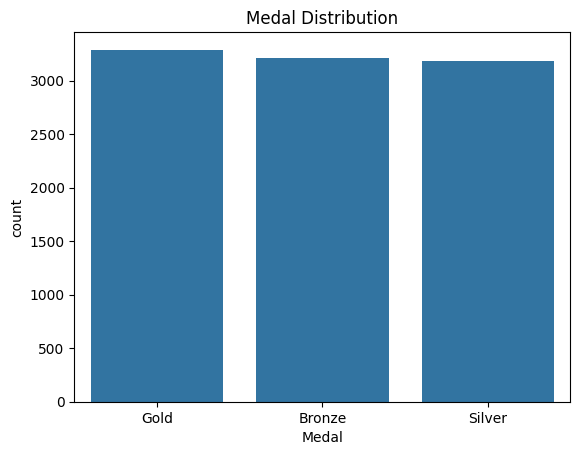

In [21]:
sns.countplot(data = data, x = "Medal")
plt.title("Medal Distribution")
plt.show()

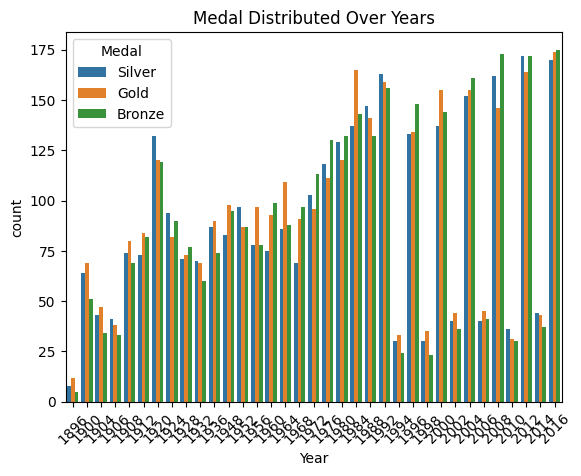

In [22]:
sns.countplot(data = data, x = "Year", hue = "Medal")
plt.title("Medal Distributed Over Years")
plt.xticks(rotation = 45)
plt.show()

In [23]:
Average_age_of_team = data.groupby('Team')['Age'].mean()
Average_age_of_team

,Age
Team,
30. Februar,23.000000
A North American Team,41.333333
Acipactli,44.000000
Acturus,NaN
Afghanistan,24.444444
...,...
Yugoslavia,24.600739
Yugoslavia-1,29.000000
Zambia,23.105263


In [25]:
Average_age_per_year = data.groupby('Year')['Age'].mean()


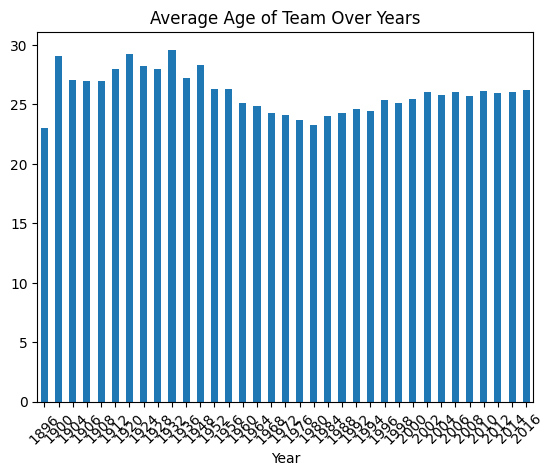

In [31]:
Average_age_per_year.plot(kind = "bar")
plt.title("Average Age of Team Over Years")
plt.xticks(rotation = 45)
plt.show()

In [36]:
Average_height_by_games = data.groupby("Height")["Sport"].value_counts()
Average_height_by_games

Height  Sport     
127.0   Gymnastics    6
131.0   Swimming      2
132.0   Shooting      2
        Rowing        1
135.0   Gymnastics    6
                     ..
216.0   Basketball    1
217.0   Basketball    2
218.0   Basketball    4
221.0   Basketball    3
223.0   Basketball    1
Name: count, Length: 2037, dtype: int64

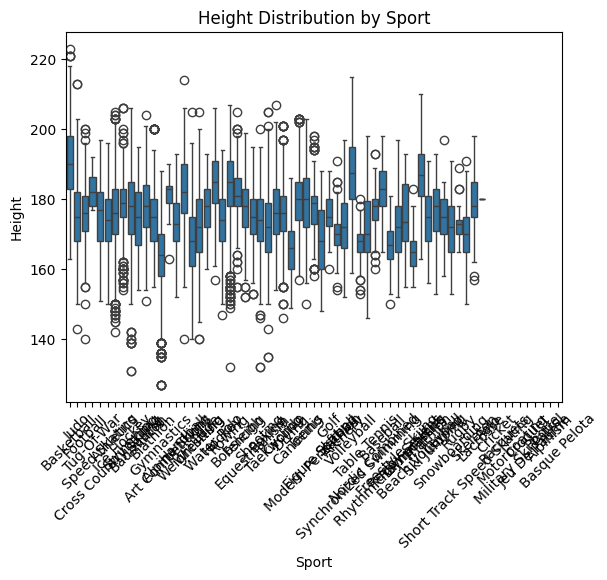

In [37]:
sns.boxplot(x = "Sport", y = "Height", data = data)
plt.title("Height Distribution by Sport")
plt.xticks(rotation = 45)
plt.show()

In [40]:
team_medal = data.groupby('Team')['Medal'].value_counts()
team_medal

Team                   Medal 
A North American Team  Bronze     3
Algeria                Bronze     2
                       Gold       1
                       Silver     1
Ali-Baba II            Bronze     1
                                 ..
Yugoslavia             Gold      31
                       Bronze    21
Zimbabwe               Gold       7
                       Silver     4
                       Bronze     1
Name: count, Length: 563, dtype: int64

In [44]:
Tallest_athlete = data[data["Height"] == data["Height"].max()]
print(Tallest_athlete[["ID", "Name", "Age", "Height","NOC", "Sport"]])

          ID                  Name   Age  Height  NOC       Sport
32376  16639  Tommy Loren Burleson  20.0   223.0  USA  Basketball
